['House ID', 'House Area', 'Number of rooms', 'Price']
Bias: 6.124735576109608
Coefficient 1: -0.3368975654081715
Coefficient 2: 0.4417979019942409


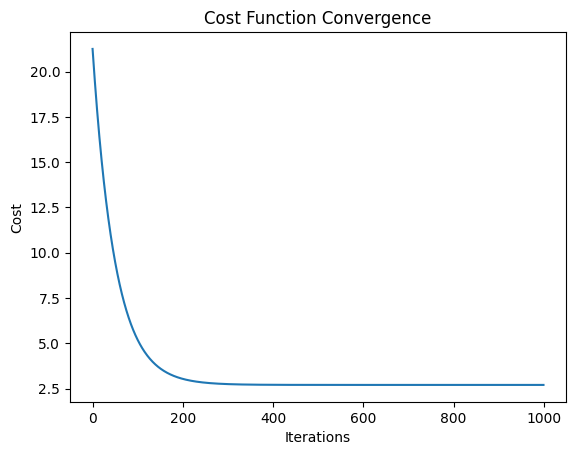

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://docs.google.com/spreadsheets/d/1AjPzzXDMNZGZPxpxC5qyYsg1vc5f_JD0uPceMAsbfQo/export?format=csv"
data = pd.read_csv(url)

# Just strip spaces (no risky renaming)
data.columns = data.columns.str.strip()
print(list(data.columns))

# Use column positions (SAFE)
X = data.iloc[:, 0:2].values
y = data.iloc[:, 2].values

# Feature scaling
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# Add bias
m = X.shape[0]
X = np.c_[np.ones(m), X]

# Parameters
theta = np.zeros(X.shape[1])
learning_rate = 0.01
iterations = 1000

def compute_cost(X, y, theta):
    predictions = X.dot(theta)
    errors = predictions - y
    return (1 / (2 * len(y))) * np.sum(errors ** 2)

def gradient_descent(X, y, theta, alpha, iterations):
    cost_history = []
    for _ in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradients = (1 / len(y)) * X.T.dot(errors)
        theta -= alpha * gradients
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

theta, cost_history = gradient_descent(X, y, theta, learning_rate, iterations)

print("Bias:", theta[0])
print("Coefficient 1:", theta[1])
print("Coefficient 2:", theta[2])

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()

